# Live Pre-Draft Prediction

Predicts the outcome of any professional LoL match **before champion select** using the trained models.

Workflow each time you want a fresh prediction:
1. **Run all cells** — elo is always recomputed from the full OraclesElixir dataset so ratings are current.
2. **Call `predict_match()`** for a single game or **`predict_series()`** for BO1/BO3/BO5.

Models used:
- **Elo** — simple win probability from tiered Elo ratings
- **XGBoost** — Elo + recent form (loaded from disk, no retraining needed)
- **GNN** — Match Graph GNN embeddings + context (loaded from disk)

> **Note on unknown teams:** If a team is not in the training vocabulary, the GNN uses the unknown (index 0) embedding — XGBoost and Elo still work fine since they only need match history from the CSV files.

In [ ]:
import sys, os, pickle
from pathlib import Path
sys.path.append(os.path.abspath("../src"))

import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
import joblib

from data.oracleselixir import load_raw, build_game_df
from models.elo import EloSystem
from models.match_gnn import build_match_graph, PreDraftPredictor

SAVE_DIR     = Path("../models/predraft")
DATA_DIR     = Path("../src/data/oracleselixir")
FEATURE_COLS = ["elo_diff",
               "blue_ewma_wr", "red_ewma_wr",
               "is_playoffs",
               "blue_elo_momentum", "red_elo_momentum",
               "blue_player_elo_avg", "red_player_elo_avg"]
device       = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

## 1. Load Data & Compute Current Elo State

Elo is always recomputed from scratch so it reflects all games in the CSV files — including today's results as soon as OraclesElixir publishes them.

In [2]:
raw     = load_raw(DATA_DIR, complete_only=True)
game_df = build_game_df(raw).sort_values("date").reset_index(drop=True)

if "playoffs" in raw.columns:
    playoff_map = raw.drop_duplicates("gameid").set_index("gameid")["playoffs"]
    game_df["is_playoffs"] = game_df["gameid"].map(playoff_map).fillna(0).astype(int)
else:
    game_df["is_playoffs"] = 0

print(f"Total games in dataset : {len(game_df):,}")
print(f"Date range             : {game_df['date'].min().date()} → {game_df['date'].max().date()}")
print()

# Show today's games (if any are already recorded)
today_str = pd.Timestamp.now().date().isoformat()
today_games = game_df[game_df["date"].dt.date.astype(str) == today_str]
if len(today_games):
    print(f"Today's games in dataset ({today_str}):")
    print(today_games[["league", "blue_team", "red_team", "blue_win"]].to_string(index=False))
else:
    print(f"No games recorded yet for {today_str} (OraclesElixir usually updates within a few hours of match end).")

print()
print("Last 5 games in dataset:")
print(game_df[["date", "league", "blue_team", "red_team", "blue_win"]].tail(5).to_string(index=False))

Total games in dataset : 62,332
Date range             : 2020-01-03 → 2026-04-30

No games recorded yet for 2026-05-01 (OraclesElixir usually updates within a few hours of match end).

Last 5 games in dataset:
               date league     blue_team            red_team  blue_win
2026-04-30 20:07:35   NACL Dorado Gaming Winthrop University         0
2026-04-30 20:10:19  LPLOL    Otter Side     ZeroZone Gaming         1
2026-04-30 20:16:20    ROL  mCon esports        Myth Esports         0
2026-04-30 20:56:14   NACL Dorado Gaming Winthrop University         0
2026-04-30 21:06:31  LPLOL  Francesinhas        Ronaldo Team         0


In [3]:
elo = EloSystem()
game_df = elo.process_and_annotate(game_df, min_games=5)

print(f"Elo ratings computed for {len(elo._ratings):,} teams")
print(f"Cold-start games excluded from model evaluation: {game_df['cold_start'].sum():,}")

Elo ratings computed for 1,790 teams
Cold-start games excluded from model evaluation: 6,264


## 2. Load Saved Models

In [4]:
# XGBoost
xgb = joblib.load(SAVE_DIR / "xgb_model.joblib")
print(f"XGBoost loaded from {SAVE_DIR / 'xgb_model.joblib'}")

# GNN vocabulary (team name → index, as used during training)
with open(SAVE_DIR / "team2idx.pkl", "rb") as f:
    team2idx = pickle.load(f)
print(f"team2idx loaded: {len(team2idx):,} teams in GNN vocabulary")

# Rebuild the match graph from ALL current data (using saved vocabulary)
full_graph = build_match_graph(game_df, team2idx, halflife_days=180, max_repeats=5)
full_graph = full_graph.to(device)
print(f"Match graph: {full_graph.edge_index.shape[1]:,} edges")

# GNN model
gnn = PreDraftPredictor(
    num_teams=len(team2idx),
    emb_dim=128,
    out_dim=64,
    hidden=128,
    dropout=0.2,
).to(device)

state = torch.load(SAVE_DIR / "gnn_weights.pt", map_location=device, weights_only=True)
gnn.load_state_dict(state)
gnn.eval()
print(f"GNN loaded from {SAVE_DIR / 'gnn_weights.pt'}")

# Precompute team embeddings once (reused across all predict_match calls)
with torch.no_grad():
    team_embeddings = gnn.encode_all_teams(full_graph)
print(f"Team embeddings: {team_embeddings.shape}")

XGBoost loaded from ../models/predraft/xgb_model.joblib
team2idx loaded: 1,789 teams in GNN vocabulary
Match graph: 155,308 edges
GNN loaded from ../models/predraft/gnn_weights.pt
Team embeddings: torch.Size([1790, 64])


## 3. Dataset State — Current Elo Rankings

Current Elo top 25 (as of 2026-04-30)
                           team          elo  games
0               Bilibili Gaming  1767.700856    246
1                         Gen.G  1757.151984    826
2           Hanwha Life Esports  1756.596843    763
3                            T1  1727.173884    917
4                        Solary  1723.940859    323
5                    G2 Esports  1717.070467    596
6                  Misa Esports  1714.313863    204
7                    KT Rolster  1709.453012    705
8                     Dplus Kia  1697.983866    846
9    T1 Esports Academy Rookies  1694.952015    400
10                       FENNEL  1694.164004     92
11  Hanwha Life Esports Academy  1692.783607    366
12  Berlin International Gaming  1687.052011    499
13                 Karmine Corp  1680.577100    418
14           Team Secret Whales  1675.498786    121
15              Partizan Sangal  1660.018349    102
16                  LNG Esports  1653.152300    164
17          MVK Esports Ac

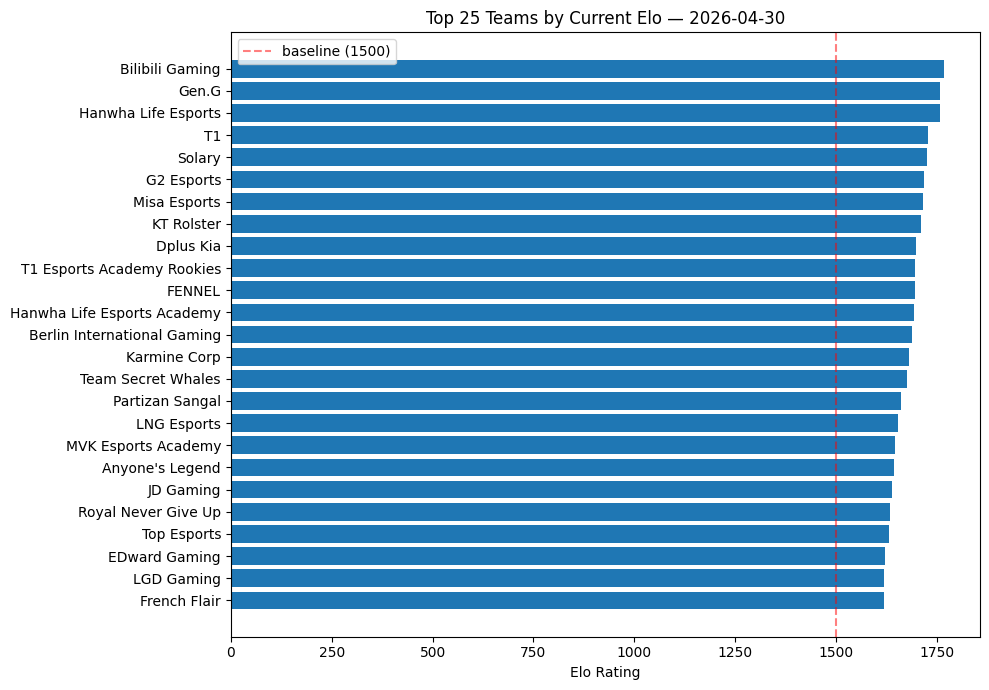

In [5]:
import matplotlib.pyplot as plt

game_counts = pd.concat([game_df["blue_team"], game_df["red_team"]]).value_counts()

rankings = (
    pd.Series(elo._ratings, name="elo")
    .reset_index()
    .rename(columns={"index": "team"})
    .assign(games=lambda d: d["team"].map(game_counts).fillna(0).astype(int))
    .query("games >= 20")
    .sort_values("elo", ascending=False)
    .head(25)
    .reset_index(drop=True)
)

print(f"Current Elo top 25 (as of {game_df['date'].max().date()})")
print(rankings[["team", "elo", "games"]].to_string(index=True))

plt.figure(figsize=(10, 7))
plt.barh(rankings["team"].iloc[::-1], rankings["elo"].iloc[::-1])
plt.axvline(1500, color="red", linestyle="--", alpha=0.5, label="baseline (1500)")
plt.xlabel("Elo Rating")
plt.title(f"Top 25 Teams by Current Elo — {game_df['date'].max().date()}")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Prediction Functions — Single Game & Series

In [ ]:
def team_info(team: str) -> str:
    """One-line summary of a team's current stats."""
    elo_val  = elo.rating(team)
    recent   = elo.recent_win_rate(team)
    games    = elo._games.get(team, 0)
    in_vocab = team in team2idx
    vocab_str = "" if in_vocab else "  [NOT in GNN vocab — unknown embedding used]"
    return f"  {team:<35} elo={elo_val:>7.1f}  recent_WR={recent:.0%}  games={games}{vocab_str}"


def _raw_probs(team_a: str, team_b: str, a_on_blue: bool, is_playoffs: bool) -> dict:
    """Internal: return all three model win probs for team_a given side assignment."""
    blue, red = (team_a, team_b) if a_on_blue else (team_b, team_a)
    sign      = 1 if a_on_blue else -1   # flip if A is on red

    elo_diff = elo.rating(blue) - elo.rating(red)
    elo_prob = elo.win_probability(blue, red)
    # Get current roster for player Elo lookup (last known lineup)
    blue_players = [player_elo.current_roster(blue, game_df).get(r) for r in ["top","jng","mid","bot","sup"]]
    red_players  = [player_elo.current_roster(red,  game_df).get(r) for r in ["top","jng","mid","bot","sup"]]

    feats    = np.array([[
        elo_diff,
        elo.ewma_win_rate(blue),
        elo.ewma_win_rate(red),
        int(is_playoffs),
        elo.elo_momentum(blue),
        elo.elo_momentum(red),
        player_elo.team_avg_elo(blue_players),
        player_elo.team_avg_elo(red_players),
    ]])

    xgb_prob = float(xgb.predict_proba(feats)[0, 1])

    bi  = torch.tensor([team2idx.get(blue, 0)], dtype=torch.long, device=device)
    ri  = torch.tensor([team2idx.get(red,  0)], dtype=torch.long, device=device)
    ctx = torch.tensor(feats, dtype=torch.float, device=device)
    with torch.no_grad():
        gnn_prob = float(gnn(team_embeddings, bi, ri, ctx).item())

    # If A is on red, model outputs P(blue_team wins) = P(A loses) → flip
    if not a_on_blue:
        elo_prob = 1 - elo_prob
        xgb_prob = 1 - xgb_prob
        gnn_prob = 1 - gnn_prob

    return {"elo": elo_prob, "xgb": xgb_prob, "gnn": gnn_prob}


def predict_match(
    blue_team:   str,
    red_team:    str,
    is_playoffs: bool = False,
    verbose:     bool = True,
) -> dict:
    """
    Predict P(blue_team wins) for a single game.

    Args:
        blue_team:   Exact team name as in OraclesElixir.
        red_team:    Exact team name as in OraclesElixir.
        is_playoffs: True for playoff / tournament stage.
        verbose:     Print formatted output.

    Returns:
        dict with keys: elo, xgb, gnn  — all = P(blue_team wins this game)
    """
    probs = _raw_probs(blue_team, red_team, a_on_blue=True, is_playoffs=is_playoffs)

    if verbose:
        line = "=" * 62
        print(line)
        print(f"  {blue_team}  (Blue)  vs  {red_team}  (Red)")
        print(f"  {'Playoffs' if is_playoffs else 'Regular season / group stage'}")
        print(line)
        print("Team stats:")
        print(team_info(blue_team))
        print(team_info(red_team))
        print()
        print(f"P({blue_team} wins):")
        print(f"  Elo baseline : {probs['elo']:.1%}")
        print(f"  XGBoost      : {probs['xgb']:.1%}")
        print(f"  GNN          : {probs['gnn']:.1%}")
        avg = sum(probs.values()) / 3
        print(f"  Ensemble avg : {avg:.1%}")
        if team2idx.get(blue_team, 0) == 0:
            print(f"  ⚠ {blue_team}: not in GNN vocab, unknown embedding used.")
        if team2idx.get(red_team, 0) == 0:
            print(f"  ⚠ {red_team}: not in GNN vocab, unknown embedding used.")

    return probs


def _series_prob_from_game_probs(p_per_game: list, wins_needed: int) -> float:
    """
    Compute P(team A wins series) given per-game win probabilities for A.

    Uses dynamic programming over (a_wins, b_wins, game_index) states.
    p_per_game[i] = P(A wins game i+1). List must be at least
    (2*wins_needed - 1) elements long (max possible games in a series).
    """
    from functools import lru_cache

    p = p_per_game  # shorthand

    @lru_cache(maxsize=None)
    def dp(game: int, a_wins: int, b_wins: int) -> float:
        if a_wins == wins_needed:
            return 1.0
        if b_wins == wins_needed:
            return 0.0
        pi = p[game] if game < len(p) else p[-1]  # repeat last if list too short
        return pi * dp(game + 1, a_wins + 1, b_wins) + \
               (1 - pi) * dp(game + 1, a_wins, b_wins + 1)

    return dp(0, 0, 0)


def predict_series(
    team_a:         str,
    team_b:         str,
    format:         str  = "BO3",
    team_a_on_blue: bool = True,
    is_playoffs:    bool = True,
) -> dict:
    """
    Predict P(team_a wins the series) for a BO1, BO3, or BO5.

    Sides alternate each game (team_a starts blue if team_a_on_blue=True).
    Game 3 / 5 uses the average of both sides (side unknown in advance).

    Args:
        team_a:         The team you want win probability for.
        team_b:         The opponent.
        format:         "BO1", "BO3", or "BO5".
        team_a_on_blue: True if team_a has blue side in game 1.
        is_playoffs:    True for playoff / tournament stage.

    Returns:
        dict with keys: elo, xgb, gnn  — all = P(team_a wins series)
    """
    fmt = format.upper()
    wins_needed = {"BO1": 1, "BO3": 2, "BO5": 3}[fmt]
    max_games   = 2 * wins_needed - 1

    # Compute per-game win probs for team_a on blue and on red
    p_blue = _raw_probs(team_a, team_b, a_on_blue=True,  is_playoffs=is_playoffs)
    p_red  = _raw_probs(team_a, team_b, a_on_blue=False, is_playoffs=is_playoffs)

    results = {}
    for model in ("elo", "xgb", "gnn"):
        pb, pr = p_blue[model], p_red[model]
        pavg   = (pb + pr) / 2

        # Side sequence: alternate starting from team_a_on_blue
        # Deciding game (G3 in BO3, G5 in BO5): use pavg (side unknown)
        sides = []
        for g in range(max_games):
            if g == max_games - 1:          # deciding game
                sides.append(pavg)
            elif (g % 2 == 0) == team_a_on_blue:
                sides.append(pb)            # team_a on blue
            else:
                sides.append(pr)            # team_a on red

        results[model] = _series_prob_from_game_probs(tuple(sides), wins_needed)

    # Print
    a_side_g1 = "Blue" if team_a_on_blue else "Red"
    line = "=" * 62
    print(line)
    print(f"  {team_a}  vs  {team_b}  [{fmt}]")
    print(f"  {team_a} starts on {a_side_g1} side in Game 1")
    print(f"  {'Playoffs' if is_playoffs else 'Regular season / group stage'}")
    print(line)
    print("Team stats:")
    print(team_info(team_a))
    print(team_info(team_b))
    print()
    print(f"Per-game win prob for {team_a}:")
    for model in ("elo", "xgb", "gnn"):
        print(f"  {model:<8}  on Blue={p_blue[model]:.1%}   on Red={p_red[model]:.1%}")
    print()
    print(f"P({team_a} wins {fmt}):")
    print(f"  Elo baseline : {results['elo']:.1%}")
    print(f"  XGBoost      : {results['xgb']:.1%}")
    print(f"  GNN          : {results['gnn']:.1%}")
    avg = sum(results.values()) / 3
    print(f"  Ensemble avg : {avg:.1%}")

    return results


def find_team(query: str, n: int = 10) -> list:
    """Search for team names containing `query` (case-insensitive)."""
    all_teams = sorted(set(elo._ratings.keys()))
    matches = [t for t in all_teams if query.lower() in t.lower()]
    if not matches:
        print(f"No teams found matching '{query}'")
    else:
        print(f"Teams matching '{query}':")
        for t in matches[:n]:
            print(f"  {t!r}  (elo={elo.rating(t):.0f}, games={elo._games.get(t, 0)})")
    return matches

## 5. Make Predictions

Use `find_team("partial name")` to look up the exact team name used in OraclesElixir.

- `predict_match(blue, red)` — single game, you specify who is Blue/Red
- `predict_series(team_a, team_b, format="BO3")` — full series, sides alternate automatically

In [7]:
# Single game — specify blue/red side explicitly
predict_match("T1", "BNK FEARX", is_playoffs=True)

  T1  (Blue)  vs  BNK FEARX  (Red)
  Playoffs
Team stats:
  T1                                  elo= 1727.2  recent_WR=90%  games=917
  BNK FEARX                           elo= 1531.1  recent_WR=20%  games=285

P(T1 wins):
  Elo baseline : 77.1%
  XGBoost      : 84.7%
  GNN          : 85.0%
  Ensemble avg : 82.3%


{'elo': 0.7712187817416328,
 'xgb': 0.8465238809585571,
 'gnn': 0.8504338264465332}

In [8]:
# BO3 series — sides alternate; Game 3 uses avg of both sides
predict_series(
    team_a         = "T1",
    team_b         = "BNK FEARX",
    format         = "BO3",
    team_a_on_blue = True,    # does T1 start on blue in Game 1?
    is_playoffs    = True,
)

  T1  vs  BNK FEARX  [BO3]
  T1 starts on Blue side in Game 1
  Playoffs
Team stats:
  T1                                  elo= 1727.2  recent_WR=90%  games=917
  BNK FEARX                           elo= 1531.1  recent_WR=20%  games=285

Per-game win prob for T1:
  elo       on Blue=77.1%   on Red=73.9%
  xgb       on Blue=84.7%   on Red=67.0%
  gnn       on Blue=85.0%   on Red=78.4%

P(T1 wins BO3):
  Elo baseline : 85.0%
  XGBoost      : 85.7%
  GNN          : 91.3%
  Ensemble avg : 87.3%


{'elo': 0.8497738750569336,
 'xgb': 0.8570841289384761,
 'gnn': 0.9127726343264265}

In [9]:
# ── Custom prediction ─────────────────────────────────────────────────────
# Edit and re-run

TEAM_A         = "T1"
TEAM_B         = "Gen.G"
FORMAT         = "BO5"      # "BO1", "BO3", or "BO5"
TEAM_A_BLUE_G1 = True       # does TEAM_A start on blue in game 1?
IS_PLAYOFFS    = True

predict_series(TEAM_A, TEAM_B, format=FORMAT, team_a_on_blue=TEAM_A_BLUE_G1, is_playoffs=IS_PLAYOFFS)

  T1  vs  Gen.G  [BO5]
  T1 starts on Blue side in Game 1
  Playoffs
Team stats:
  T1                                  elo= 1727.2  recent_WR=90%  games=917
  Gen.G                               elo= 1757.2  recent_WR=70%  games=826

Per-game win prob for T1:
  elo       on Blue=47.8%   on Red=43.6%
  xgb       on Blue=50.5%   on Red=40.6%
  gnn       on Blue=46.8%   on Red=43.0%

P(T1 wins BO5):
  Elo baseline : 42.0%
  XGBoost      : 41.7%
  GNN          : 40.6%
  Ensemble avg : 41.4%


{'elo': 0.41979480884290094,
 'xgb': 0.4169585244012428,
 'gnn': 0.40563576333281615}

## 6. Today's Recorded Matches

OraclesElixir typically publishes data within a few hours of a match ending.

In [10]:
recent_cutoff = pd.Timestamp.now() - pd.Timedelta(days=2)
recent = game_df[game_df["date"] >= recent_cutoff].copy()
recent["result"] = recent["blue_win"].map({1: "Blue wins", 0: "Red wins"})

print(f"Games in dataset since {recent_cutoff.date()}:")
print(recent[["date", "league", "blue_team", "red_team", "result"]].to_string(index=False))
print()

lec_recent = recent[recent["league"] == "LEC"]
if len(lec_recent):
    print("LEC games in last 2 days:")
    print(lec_recent[["date", "blue_team", "red_team", "result"]].to_string(index=False))
else:
    last_lec = game_df[game_df["league"] == "LEC"]["date"].max()
    print(f"No LEC games in last 2 days. Last LEC game recorded: {last_lec}")

Games in dataset since 2026-04-29:
               date league                               blue_team                                red_team    result
2026-04-29 20:55:34    EWC                                FlyQuest                               Sentinels  Red wins
2026-04-29 21:00:40   NACL                          Citadel Gaming                                     NRG Blue wins
2026-04-29 21:09:39  LPLOL                            Francesinhas                         ZeroZone Gaming Blue wins
2026-04-29 21:54:10   NACL                    Maryville University                             CCG Esports Blue wins
2026-04-29 22:37:59   NACL                    Maryville University                             CCG Esports Blue wins
2026-04-30 05:07:17   LCKC                    Gen.G Global Academy                   Dplus Kia Challengers Blue wins
2026-04-30 05:07:52   LCKC                  KT Rolster Challengers                  DN SOOPers Challengers Blue wins
2026-04-30 05:08:37   LCKC   